# Fluid Substitution & Pre-Stack Seismic Modeling

**A Gassmann fluid-substitution and AVO rock-physics workflow for a shaly-sand clastic reservoir**

This notebook builds a synthetic type-well log for a shallow, high-porosity Tertiary
clastic reservoir, performs Gassmann fluid substitution (brine &rarr; oil &rarr; gas),
constructs a Vp/Vs-vs-acoustic-impedance rock physics template calibrated against
log and core data, and generates pre-stack synthetic angle gathers to evaluate the
resulting AVO response. It mirrors, end to end, the workflow of the `run_analysis.py`
script in the project root -- this notebook adds narrative commentary and inline
figures; the script is the canonical, faster-to-run entry point.

No proprietary or measured field dataset is used anywhere in this project. Every
curve is generated from standard, cited empirical/petrophysical relations
(Athy's law compaction trend, Batzle & Wang 1992 fluid properties, a quartz-clay
Voigt-Reuss-Hill mineral mixture, the Krief et al. 1990 dry-frame model, and
Gassmann 1951 fluid substitution), calibrated to literature-typical parameter
ranges for this depositional setting.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import fluid_properties as fl
from src import rock_physics_model as rpm
from src import synthetic_well as sw
from src import rock_physics_template as rpt
from src import avo_modeling as avo
from src import plotting as viz
from IPython.display import Image, display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)


## 1. Synthetic type-well construction

The well spans 2000-2200 m TVD, with a single 16 m clean, high-porosity Tertiary
sand (2140-2156 m) embedded in a shaly background, plus two thin non-reservoir
silty streaks included purely for log realism. Porosity follows an Athy's-law
compaction trend with depth, and lithology (Vshale) controls a quartz-clay
Voigt-Reuss-Hill mineral mixture at every depth.

In [2]:
df = sw.build_synthetic_well()
reservoir_top, reservoir_base = df.attrs["reservoir_top_m"], df.attrs["reservoir_base_m"]
print(f"Reservoir interval: {reservoir_top:.1f} - {reservoir_base:.1f} m ({reservoir_base-reservoir_top:.0f} m gross)")
df[["DEPTH_M", "VSHALE", "PHIE", "VP_BRINE_MPS", "VS_BRINE_MPS", "RHO_BRINE_KGM3"]].describe()


Reservoir interval: 2140.0 - 2156.0 m (16 m gross)


,DEPTH_M,VSHALE,PHIE,VP_BRINE_MPS,VS_BRINE_MPS,RHO_BRINE_KGM3
count,1313.0000,1313.0000,1313.0000,1313.0000,1313.0000,1313.0000
mean,2099.9744,0.7266,0.2872,2603.4530,1199.1098,2142.8000
std,57.7862,0.2126,0.0210,115.5785,147.1808,25.1759
min,2000.0000,0.0200,0.2461,2407.9734,996.9389,2059.6908
25%,2049.9872,0.7477,0.2735,2530.4681,1114.0797,2130.7361
50%,2099.9744,0.8000,0.2828,2575.0791,1156.4802,2146.0599
75%,2149.9616,0.8355,0.2936,2642.9208,1222.0862,2160.3665
max,2199.9488,0.9516,0.3570,3048.7079,1771.8697,2202.1899


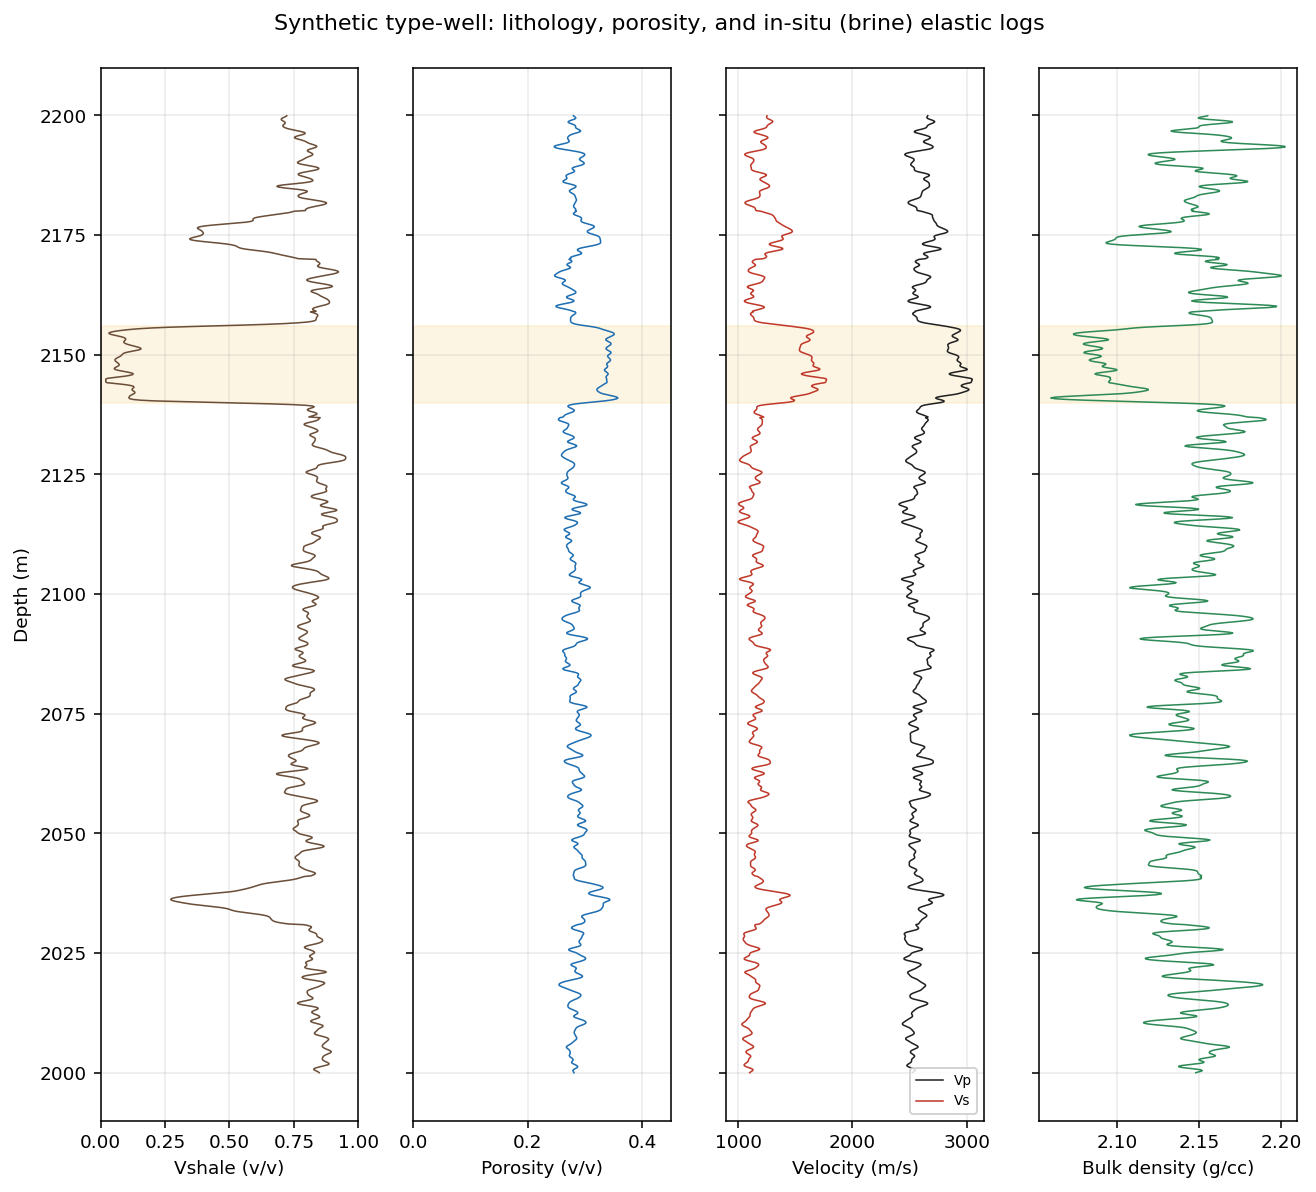

In [3]:
viz.plot_log_tracks(df, reservoir_top, reservoir_base, "../figures/01_log_tracks.png")
display(Image("../figures/01_log_tracks.png"))


## 2. In-situ conditions and pore-fluid properties

A hydrostatic pressure gradient (10.0 MPa/km) and a geothermal gradient
(30 degC/km, 8 degC surface temperature) define the in-situ pressure and
temperature at every depth, consistent with a normally-pressured North Sea-type
Tertiary section. Brine properties use the Batzle & Wang (1992) relations exactly
as implemented in the open-source `bruges` library; oil and gas use simplified,
clearly-documented representative PVT relations (see `src/fluid_properties.py`),
since no measured PVT report exists for this synthetic case.

In [4]:
mid_depth = 2148.0
t_mid, p_mid = fl.in_situ_conditions(mid_depth)
rho_b, k_b = fl.brine_properties(t_mid, p_mid, sw.SALINITY_PPM)
rho_o, k_o = fl.dead_oil_properties(t_mid, p_mid, api_gravity=sw.OIL_API)
rho_g, k_g = fl.gas_properties(t_mid, p_mid, gas_gravity=sw.GAS_GRAVITY)

print(f"In-situ conditions @ {mid_depth:.0f} m:  T = {t_mid:.1f} degC,  P = {p_mid/1e6:.1f} MPa\n")
for label, rho, k in (("Brine", rho_b, k_b), (f"Oil ({sw.OIL_API:.0f} API)", rho_o, k_o),
                      (f"Gas (gravity {sw.GAS_GRAVITY})", rho_g, k_g)):
    print(f"{label:14s}  rho = {rho:7.1f} kg/m3   K = {k/1e9:7.4f} GPa")


In-situ conditions @ 2148 m:  T = 72.4 degC,  P = 21.5 MPa

Brine           rho =  1010.3 kg/m3   K =  2.6733 GPa
Oil (32 API)    rho =   840.3 kg/m3   K =  1.5772 GPa
Gas (gravity 0.65)  rho =   140.8 kg/m3   K =  0.0268 GPa


## 3. Gassmann fluid substitution

Within the reservoir interval, the in-situ (brine-saturated) elastic log is
carried through the Gassmann (1951) equation to predict the rock's elastic
response if the pore space were instead filled with oil or gas, holding the
rock frame (mineral moduli, dry-frame moduli, porosity) fixed. This is the
classic "what would this sand look like if it were charged with hydrocarbon"
fluid-substitution question.

In [5]:
reservoir_props = {}
for fluid in ("BRINE", "OIL", "GAS"):
    vp, vs, rho = sw.reservoir_average_properties(df, fluid, 2142.0, 2154.0)
    reservoir_props[fluid] = dict(vp=vp, vs=vs, rho=rho, ai=vp*rho, vpvs=vp/vs)

summary = pd.DataFrame(reservoir_props).T
summary["rho"] = summary["rho"] / 1000.0
summary["ai"] = summary["ai"] / 1000.0
summary.columns = ["Vp (m/s)", "Vs (m/s)", "rho (g/cc)", "AI (m/s.g/cc x1e3)", "Vp/Vs"]
summary.round(3)


,Vp (m/s),Vs (m/s),rho (g/cc),AI (m/s.g/cc x1e3),Vp/Vs
BRINE,2928.893,1636.663,2.093,6130.525,1.790
OIL,2804.284,1659.539,2.036,5708.954,1.690
GAS,2681.326,1764.881,1.800,4826.324,1.519


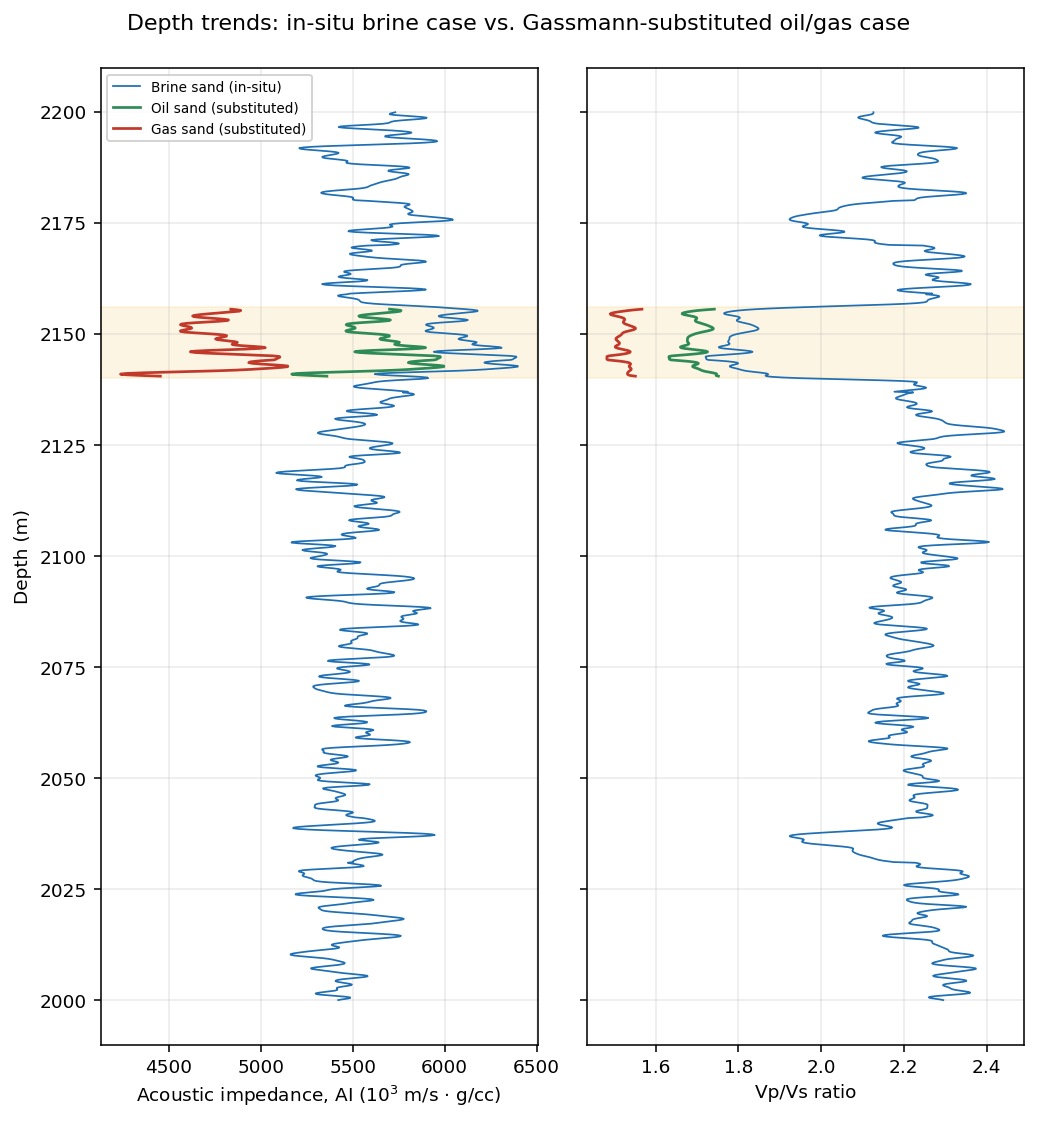

In [6]:
viz.plot_depth_trends(df, reservoir_top, reservoir_base, "../figures/02_depth_trends.png")
display(Image("../figures/02_depth_trends.png"))


Substituting brine for gas lowers Vp by roughly 8%, density by roughly 14%,
and Vp/Vs by roughly 15% relative to the in-situ brine case -- consistent with
the classic rock-physics fluid signature (gas softens the pore-fluid bulk
modulus far more than it changes the frame, so Vp and Vp/Vs both drop sharply,
while Vs is comparatively insensitive to the fluid).

## 4. Rock physics template (Vp/Vs vs. acoustic impedance)

A porosity-swept forward model (same Krief + Gassmann formalism, fixed
mineralogy and in-situ conditions) traces out brine-sand, oil-sand, gas-sand,
and shale trend lines in Vp/Vs-vs-AI space. Sparse synthetic "core plug" samples
(with independent measurement scatter) are overlaid to mimic a log-and-core
calibrated template.

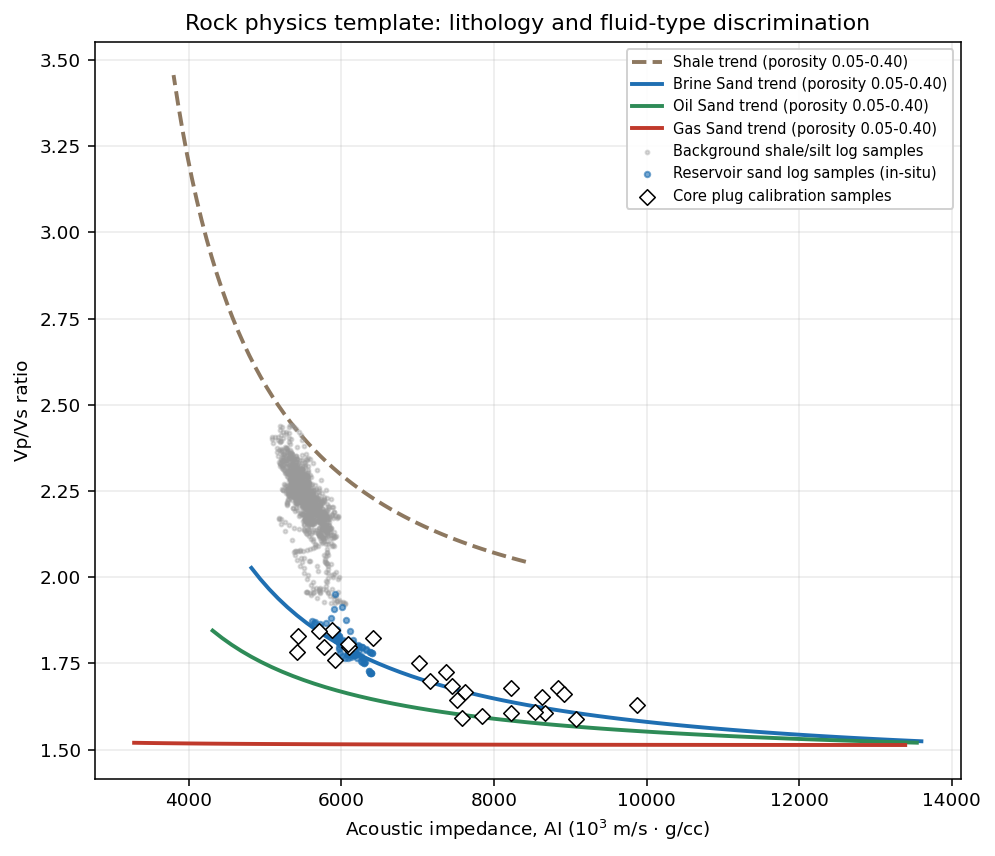

In [7]:
porosity_range = np.linspace(0.05, 0.40, 60)
template_curves = rpt.build_template_curves(
    porosity_range, sand_vshale=0.08, shale_vshale=0.95,
    brine_props=(rho_b, k_b), oil_props=(rho_o, k_o), gas_props=(rho_g, k_g))
core_samples = rpt.synthesize_core_samples(
    26, np.linspace(0.20, 0.38, 60), sand_vshale=0.08, fluid_props=(rho_b, k_b))

viz.plot_rock_physics_template(df, template_curves, core_samples, reservoir_top,
                                reservoir_base, "../figures/03_rock_physics_template.png")
display(Image("../figures/03_rock_physics_template.png"))


## 5. Lambda-Rho / Mu-Rho fluid discrimination

Decomposing the elastic response into incompressibility (`lambda*rho`) and
rigidity (`mu*rho`) attributes (Goodway et al., 1997) isolates the fluid effect
cleanly: under Gassmann's assumptions the shear modulus -- and hence `mu*rho`,
since `mu*rho = rho * Vs^2 = mu` identically -- is fluid-independent, so the
brine/oil/gas points fall at (almost) the same `mu*rho` while spreading widely
in `lambda*rho`. Shale, with different mineralogy and frame properties, plots
at a distinctly different `mu*rho`, separating lithology from fluid effects.

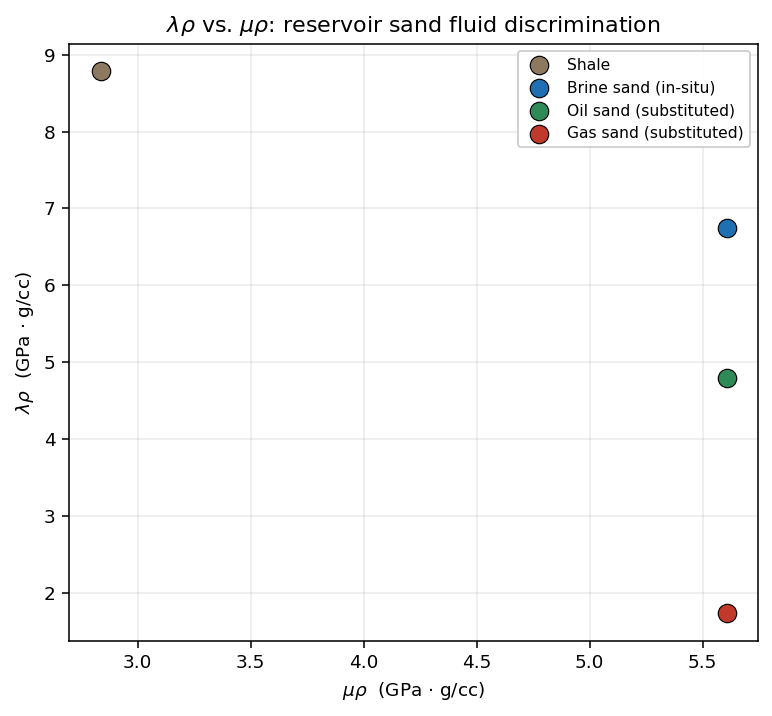

In [8]:
shale_vp, shale_vs, shale_rho = sw.reservoir_average_properties(df, "BRINE", 2128.0, 2138.0)
lmr_points = {"SHALE": (rpm.lambda_rho(shale_vp, shale_vs, shale_rho), rpm.mu_rho(shale_vs, shale_rho))}
for fluid, p in reservoir_props.items():
    lmr_points[fluid] = (rpm.lambda_rho(p["vp"], p["vs"], p["rho"]), rpm.mu_rho(p["vs"], p["rho"]))

viz.plot_lambda_mu_rho(lmr_points, "../figures/04_lambda_mu_rho.png")
display(Image("../figures/04_lambda_mu_rho.png"))


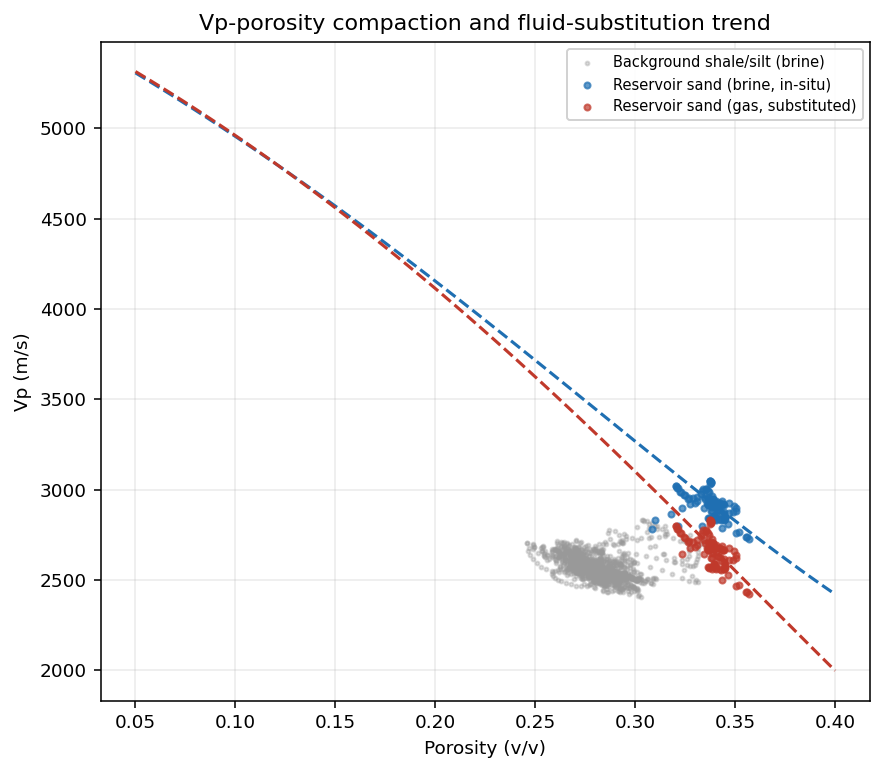

In [9]:
viz.plot_vp_porosity(df, template_curves, reservoir_top, reservoir_base, "../figures/05_vp_porosity.png")
display(Image("../figures/05_vp_porosity.png"))


## 6. Pre-stack synthetic seismic modelling (AVO)

Using the Shuey (1985) three-term linearized approximation to the Aki &
Richards (1980) reflectivity equation, synthetic angle gathers are built for
the top- and base-of-reservoir reflections in each fluid case, convolved with
a 30 Hz zero-phase Ricker wavelet. A constant overburden velocity is assumed
purely for the depth-to-time conversion used to position the two reflectors on
the trace; the reflectivity modelling itself is performed directly from the
layer elastic properties.

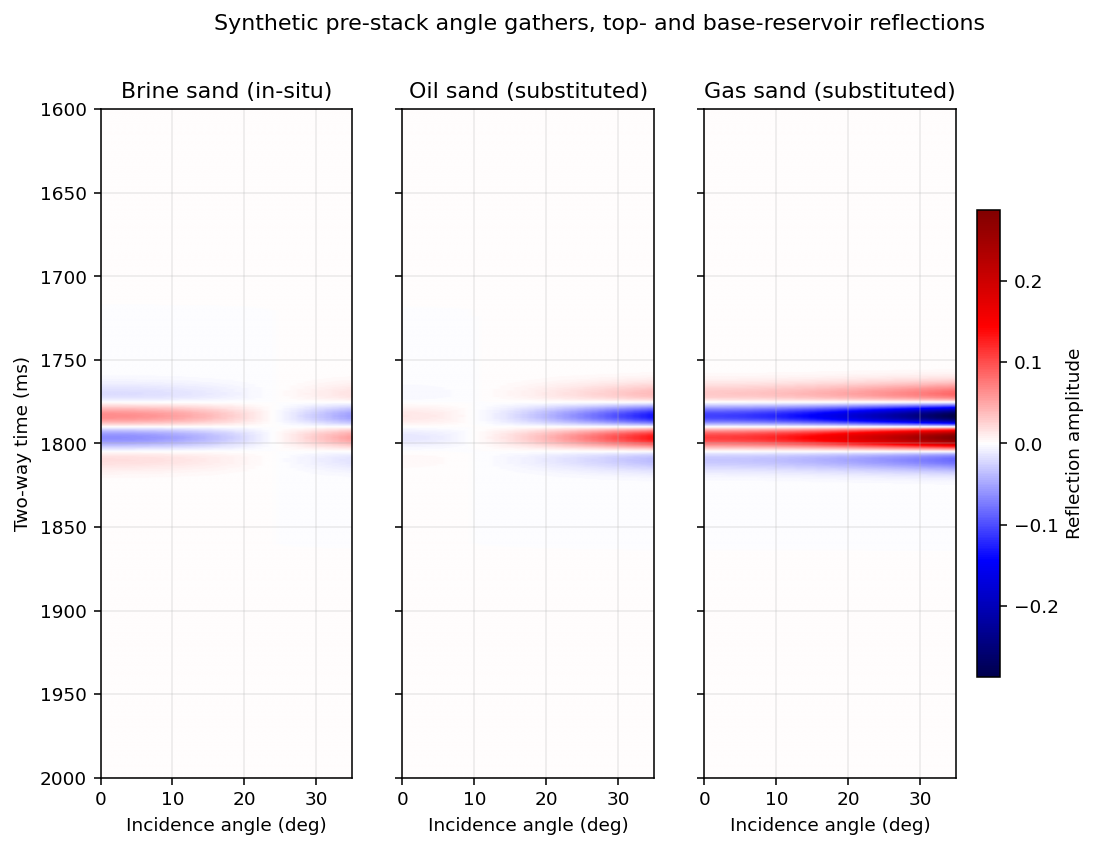

In [10]:
SHALE_CAP_ZONE = (2128.0, 2138.0)
UNDERLYING_SHALE_ZONE = (2160.0, 2172.0)
OVERBURDEN_AVG_VELOCITY_MPS = 2400.0
RICKER_FREQUENCY_HZ = 30.0
ANGLES_DEG = np.arange(0, 36, 1)

def two_way_time(depth_m):
    return 2.0 * depth_m / OVERBURDEN_AVG_VELOCITY_MPS

under_vp, under_vs, under_rho = sw.reservoir_average_properties(df, "BRINE", *UNDERLYING_SHALE_ZONE)

dt_s = 0.0005
time_axis = np.arange(1.60, 2.00 + dt_s/2, dt_s)
_, wavelet = avo.ricker_wavelet(RICKER_FREQUENCY_HZ, dt_s=dt_s, length_s=0.128)

gathers, stacks, avo_points = {}, {}, {}
for fluid in ("BRINE", "OIL", "GAS"):
    p = reservoir_props[fluid]
    interfaces = [
        dict(vp1=shale_vp, vs1=shale_vs, rho1=shale_rho,
             vp2=p["vp"], vs2=p["vs"], rho2=p["rho"], twt_s=two_way_time(reservoir_top)),
        dict(vp1=p["vp"], vs1=p["vs"], rho1=p["rho"],
             vp2=under_vp, vs2=under_vs, rho2=under_rho, twt_s=two_way_time(reservoir_base)),
    ]
    gather, (A, B, C) = avo.build_angle_gather(interfaces, ANGLES_DEG, time_axis, wavelet)
    gathers[fluid] = gather
    stacks[fluid] = {
        "Near (0-12 deg)": avo.stack_gather(gather, ANGLES_DEG, (0, 12)),
        "Mid (12-24 deg)": avo.stack_gather(gather, ANGLES_DEG, (12, 24)),
        "Far (24-35 deg)": avo.stack_gather(gather, ANGLES_DEG, (24, 35)),
    }
    avo_points[fluid] = (A, B)

viz.plot_angle_gathers(gathers, time_axis, ANGLES_DEG, "../figures/06_angle_gathers.png")
display(Image("../figures/06_angle_gathers.png"))


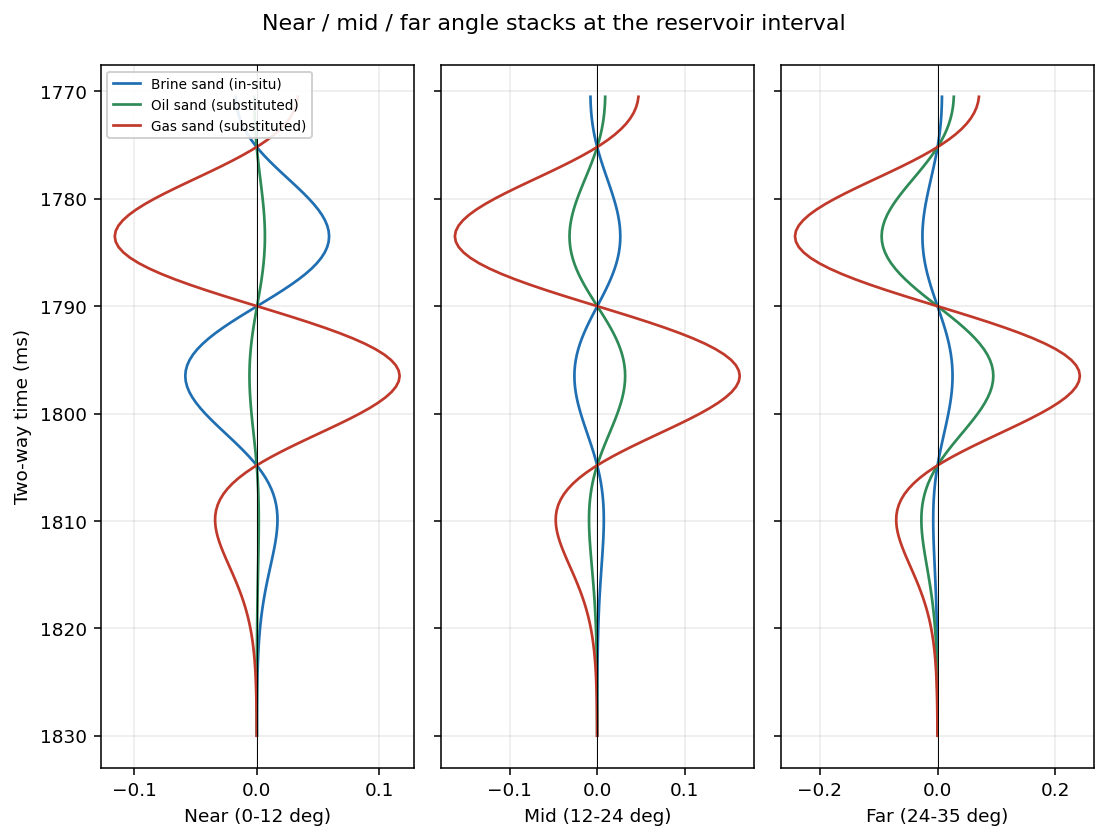

In [11]:
viz.plot_near_mid_far(stacks, time_axis, (1770, 1830), "../figures/07_near_mid_far_stacks.png")
display(Image("../figures/07_near_mid_far_stacks.png"))


## 7. AVO classification

The two-term intercept (A) and gradient (B) at the top-of-reservoir reflection
classify each fluid case using the Rutherford & Williams (1989) / Castagna &
Swan (1997) scheme.

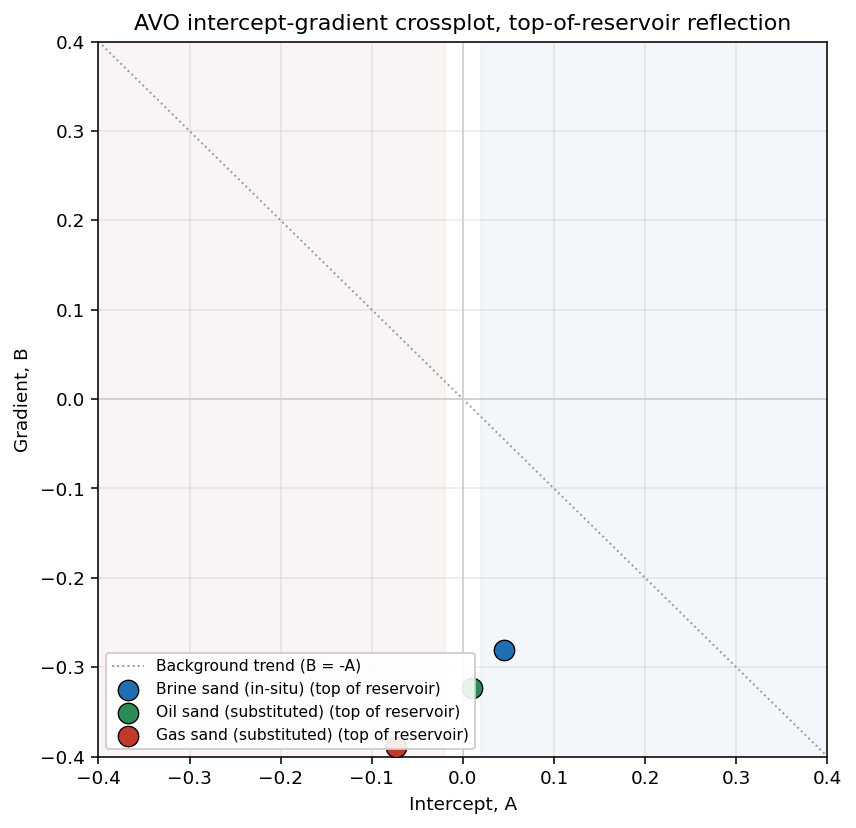

BRINE  A=+0.045  B=-0.280  ->  Class I (high-impedance sand, amplitude decreases with offset)
OIL    A=+0.010  B=-0.324  ->  Class II / IIp (near-zero impedance contrast, possible polarity reversal with offset)
GAS    A=-0.074  B=-0.390  ->  Class III (low-impedance sand, amplitude increases with offset -- classic bright-spot)


In [12]:
viz.plot_avo_crossplot(avo_points, "../figures/08_avo_crossplot.png")
display(Image("../figures/08_avo_crossplot.png"))

for fluid, (a, b) in avo_points.items():
    print(f"{fluid:6s} A={a:+.3f}  B={b:+.3f}  ->  {avo.classify_avo(a, b)}")


**Interpretation.** The brine case sits in Class I territory (small positive
intercept, sand slightly stiffer than the shale cap). Substituting in oil moves
the intercept to within a few hundredths of zero -- a genuinely *subtle* AVO
signature that is easy to miss on a single near-offset stack and only becomes
diagnostic once the full-angle gradient is examined. Gas substitution pushes
the response firmly into Class III bright-spot territory: strong negative
intercept reinforced by a strong negative gradient, i.e. reflection amplitude
growing markedly with offset -- the classic, unambiguous unconsolidated-sand
gas signature. Discriminating the subtle oil case from the unambiguous gas
case, and both from the brine background, is precisely the kind of
intercept-gradient AVO analysis this workflow is designed to support.

## 8. Summary

| Fluid case | Vp (m/s) | Vs (m/s) | rho (g/cc) | AI | Vp/Vs | AVO class |
|---|---|---|---|---|---|---|
| Brine | 2929 | 1637 | 2.093 | 6131 | 1.790 | Class I |
| Oil | 2804 | 1660 | 2.036 | 5709 | 1.690 | Class II / IIp |
| Gas | 2681 | 1765 | 1.800 | 4826 | 1.519 | Class III |

Data products (`data/synthetic_well_logs.csv`, `data/synthetic_well.las`,
`data/core_calibration_samples.csv`) and every figure above are regenerated
by running `python run_analysis.py` from the project root -- this notebook
and the script share the same underlying `src/` modules, so both always stay
in sync.